In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline

import warnings 
warnings.filterwarnings("ignore")

df = pd.read_csv('../data/Preprocessed.csv')
df.head()

,Age,Number of Dependents,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,...,Streaming TV_Yes,Streaming Movies_Yes,Streaming Music_Yes,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check,Churn Label
0,78,0,34.023810,-118.156582,68701,0,1,0.00,8,39.65,...,0,1,0,0,0,0,1,0,0,1
1,74,1,34.044271,-118.185237,55668,1,8,48.85,17,80.65,...,0,0,0,1,0,0,1,1,0,1
2,71,3,34.108833,-118.229715,47534,0,18,11.33,52,95.45,...,1,1,1,1,0,0,1,0,0,1
3,78,1,33.936291,-118.332639,27778,1,25,19.76,12,98.50,...,1,1,0,1,0,0,1,0,0,1
4,80,1,33.972119,-118.020188,26265,1,37,6.33,14,76.50,...,0,0,0,1,0,0,1,0,0,1


In [3]:
df.shape

(7043, 46)

In [5]:

columns_to_drop = [
    'Satisfaction Score'
]

df.drop(columns=columns_to_drop, inplace=True)

print(df.shape)

(7043, 45)


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                7043 non-null   int64  
 1   Number of Dependents               7043 non-null   int64  
 2   Latitude                           7043 non-null   float64
 3   Longitude                          7043 non-null   float64
 4   Population                         7043 non-null   int64  
 5   Number of Referrals                7043 non-null   int64  
 6   Tenure in Months                   7043 non-null   int64  
 7   Avg Monthly Long Distance Charges  7043 non-null   float64
 8   Avg Monthly GB Download            7043 non-null   int64  
 9   Monthly Charge                     7043 non-null   float64
 10  Total Charges                      7043 non-null   float64
 11  Total Refunds                      7043 non-null   float64
 12  Tot

In [23]:
X = df.drop('Churn Label', axis=1)
y = df['Churn Label']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

print("\nTraining Target Distribution")
print(y_train.value_counts(normalize=True))

print("\nTesting Target Distribution")
print(y_test.value_counts(normalize=True))

Training Set : (5634, 44)
Testing Set  : (1409, 44)

Training Target Distribution
Churn Label
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing Target Distribution
Churn Label
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(X_train_smote.shape)
print(y_train_smote.value_counts())

(8278, 44)
Churn Label
0    4139
1    4139
Name: count, dtype: int64


In [10]:
import optuna
import pandas as pd

from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

results = []

In [11]:
def evaluate_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": average_precision_score(y_test, y_prob),
        "MCC": matthews_corrcoef(y_test, y_pred)
    }

    results.append(metrics)

    print(f"\n{'='*60}")
    print(model_name)
    print('='*60)

    print(classification_report(y_test, y_pred))

    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))

In [12]:
def tune_model(
    model_class,
    objective_function,
    model_name,
    n_trials=50,
    fixed_params=None
):
    if fixed_params is None:
        fixed_params = {}

    study = optuna.create_study(
    direction="maximize",
    study_name=model_name
)
    study.optimize(objective_function, n_trials=n_trials, show_progress_bar=True)
    
    print("\nBest CV F1:", study.best_value)
    print("Best Parameters:")
    print(study.best_params)

    best_model = model_class(
        **study.best_params,
        **fixed_params
    )
    
    best_model.fit(X_train_smote, y_train_smote)

    evaluate_model(best_model, X_test, y_test, model_name)

    return best_model, study

In [13]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [24]:
from sklearn.linear_model import LogisticRegression

def objective_lr(trial):

    params = {

        "C": trial.suggest_float(
            "C",
            1e-4,
            100,
            log=True
        ),

        "solver": trial.suggest_categorical(
            "solver",
            ["liblinear", "lbfgs"]
        ),

        "max_iter": 1000

    }

    model = LogisticRegression(
        **params,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    ).mean()

    return score

In [15]:
best_lr, study_lr = tune_model(
    LogisticRegression,
    objective_lr,
    "Logistic Regression"
)

[I 2026-07-28 09:56:08,873] A new study created in memory with name: Logistic Regression


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-28 09:56:14,748] Trial 0 finished with value: 0.799831539619636 and parameters: {'C': 0.0038421978855250187, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.799831539619636.
[I 2026-07-28 09:56:15,338] Trial 1 finished with value: 0.8757670824042915 and parameters: {'C': 0.5031358798130013, 'solver': 'liblinear'}. Best is trial 1 with value: 0.8757670824042915.
[I 2026-07-28 09:56:17,324] Trial 2 finished with value: 0.7998832639592764 and parameters: {'C': 0.03734358556763349, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.8757670824042915.
[I 2026-07-28 09:56:17,917] Trial 3 finished with value: 0.8760900278692709 and parameters: {'C': 5.1618636665469015, 'solver': 'liblinear'}. Best is trial 3 with value: 0.8760900278692709.
[I 2026-07-28 09:56:18,455] Trial 4 finished with value: 0.8757817979129594 and parameters: {'C': 0.1588193344824425, 'solver': 'liblinear'}. Best is trial 3 with value: 0.8760900278692709.
[I 2026-07-28 09:56:18,892] Trial 5 finished with value:

In [16]:
from sklearn.tree import DecisionTreeClassifier

def objective_dt(trial):

    params = {

        "criterion": trial.suggest_categorical(
            "criterion",
            ["gini", "entropy", "log_loss"]
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            30
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            2,
            20
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            1,
            10
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            [None, "sqrt", "log2"]
        )

    }

    model = DecisionTreeClassifier(
        **params,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    ).mean()

    return score

In [17]:
best_dt, study_dt = tune_model(
    DecisionTreeClassifier,
    objective_dt,
    "Decision Tree"
)

[I 2026-07-28 09:57:20,850] A new study created in memory with name: Decision Tree


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-28 09:57:21,659] Trial 0 finished with value: 0.8508324538379342 and parameters: {'criterion': 'log_loss', 'max_depth': 15, 'min_samples_split': 18, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 0 with value: 0.8508324538379342.
[I 2026-07-28 09:57:21,878] Trial 1 finished with value: 0.8618027984921802 and parameters: {'criterion': 'log_loss', 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 1 with value: 0.8618027984921802.
[I 2026-07-28 09:57:22,199] Trial 2 finished with value: 0.8497321623352632 and parameters: {'criterion': 'gini', 'max_depth': 27, 'min_samples_split': 17, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 1 with value: 0.8618027984921802.
[I 2026-07-28 09:57:22,301] Trial 3 finished with value: 0.8365159184073068 and parameters: {'criterion': 'gini', 'max_depth': 11, 'min_samples_split': 13, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 1 with value: 0.8618027984

In [19]:
from sklearn.ensemble import RandomForestClassifier
def objective_rf(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            500,
            step=50
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            5,
            30
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            2,
            20
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            1,
            10
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        ),

        "bootstrap": trial.suggest_categorical(
            "bootstrap",
            [True, False]
        )

    }

    model = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )

    score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    ).mean()

    return score

In [29]:
best_rf, study_rf = tune_model(
    RandomForestClassifier,
    objective_rf,
    "Random Forest",
    n_trials=50
)

[I 2026-07-28 10:49:47,160] A new study created in memory with name: Random Forest


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-28 10:49:53,039] Trial 0 finished with value: 0.8873737375386275 and parameters: {'n_estimators': 300, 'max_depth': 29, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.8873737375386275.
[I 2026-07-28 10:49:54,809] Trial 1 finished with value: 0.881383348127858 and parameters: {'n_estimators': 100, 'max_depth': 28, 'min_samples_split': 7, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.8873737375386275.
[I 2026-07-28 10:50:00,069] Trial 2 finished with value: 0.8502124700032881 and parameters: {'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 0.8873737375386275.
[I 2026-07-28 10:50:04,162] Trial 3 finished with value: 0.8781919481111646 and parameters: {'n_estimators': 300, 'max_depth': 26, 'min_samples_split': 9, 'min_samples_leaf': 10, 'max_feature

In [25]:
from xgboost import XGBClassifier
def objective_xgb(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 500, step=50
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 3, 12
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3, log=True
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),

        "gamma": trial.suggest_float(
            "gamma", 0.0, 5.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-8, 10.0, log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-8, 10.0, log=True
        )

    }

    model = XGBClassifier(
        **params,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    )

    score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    ).mean()

    return score

In [26]:
best_xgb, study_xgb = tune_model(
    XGBClassifier,
    objective_xgb,
    "XGBoost",
    n_trials=50,
    fixed_params={
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1
    }
)

[I 2026-07-28 10:26:34,745] A new study created in memory with name: XGBoost


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-28 10:26:39,518] Trial 0 finished with value: 0.8848283503794606 and parameters: {'n_estimators': 150, 'max_depth': 10, 'learning_rate': 0.014165499406490563, 'subsample': 0.6495480516871736, 'colsample_bytree': 0.6883083835671718, 'gamma': 3.38086171875636, 'min_child_weight': 2, 'reg_alpha': 6.222450946128564e-05, 'reg_lambda': 0.06400024161060275}. Best is trial 0 with value: 0.8848283503794606.
[I 2026-07-28 10:26:40,917] Trial 1 finished with value: 0.8901790350522996 and parameters: {'n_estimators': 350, 'max_depth': 11, 'learning_rate': 0.09622466716756455, 'subsample': 0.6405950552386197, 'colsample_bytree': 0.8787114369917206, 'gamma': 2.647464591720996, 'min_child_weight': 8, 'reg_alpha': 0.7949325632931846, 'reg_lambda': 2.421645267017781e-07}. Best is trial 1 with value: 0.8901790350522996.
[I 2026-07-28 10:26:41,990] Trial 2 finished with value: 0.885051296183007 and parameters: {'n_estimators': 250, 'max_depth': 4, 'learning_rate': 0.02828097168526132, 'subsamp

In [27]:
from lightgbm import LGBMClassifier
def objective_lgb(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 500, step=50
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3, log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 3, 15
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves", 20, 150
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples", 5, 50
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-8, 10.0, log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-8, 10.0, log=True
        )

    }

    model = LGBMClassifier(
        **params,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    ).mean()

    return score

best_lgb, study_lgb = tune_model(
    LGBMClassifier,
    objective_lgb,
    "LightGBM",
    n_trials=100,
    fixed_params={
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1
    }
)

[I 2026-07-28 10:29:16,555] A new study created in memory with name: LightGBM


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-28 10:29:18,734] Trial 0 finished with value: 0.8949274785107496 and parameters: {'n_estimators': 250, 'learning_rate': 0.13422923000096085, 'max_depth': 7, 'num_leaves': 37, 'min_child_samples': 12, 'subsample': 0.9736117224983393, 'colsample_bytree': 0.808691054182326, 'reg_alpha': 2.646494941324626e-07, 'reg_lambda': 1.8761942721240844e-07}. Best is trial 0 with value: 0.8949274785107496.
[I 2026-07-28 10:29:23,173] Trial 1 finished with value: 0.89242980622745 and parameters: {'n_estimators': 500, 'learning_rate': 0.01057335793084759, 'max_depth': 9, 'num_leaves': 95, 'min_child_samples': 49, 'subsample': 0.788713438282914, 'colsample_bytree': 0.7417465095998477, 'reg_alpha': 0.0017276842574959121, 'reg_lambda': 0.5118544595129404}. Best is trial 0 with value: 0.8949274785107496.
[I 2026-07-28 10:29:25,450] Trial 2 finished with value: 0.894218991375789 and parameters: {'n_estimators': 450, 'learning_rate': 0.09531923188389958, 'max_depth': 5, 'num_leaves': 76, 'min_chil

In [28]:
from catboost import CatBoostClassifier
def objective_cat(trial):

    params = {

        "iterations": trial.suggest_int(
            "iterations", 100, 500, step=50
        ),

        "depth": trial.suggest_int(
            "depth", 4, 10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3, log=True
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg", 1.0, 10.0
        ),

        "random_strength": trial.suggest_float(
            "random_strength", 1e-8, 10.0, log=True
        ),

        "bagging_temperature": trial.suggest_float(
            "bagging_temperature", 0.0, 10.0
        ),

        "border_count": trial.suggest_int(
            "border_count", 32, 255
        )

    }

    model = CatBoostClassifier(
        **params,
        loss_function="Logloss",
        eval_metric="F1",
        random_seed=42,
        verbose=False
    )

    score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    ).mean()

    return score
best_cat, study_cat = tune_model(
    CatBoostClassifier,
    objective_cat,
    "CatBoost",
    n_trials=50,
    fixed_params={
        "loss_function": "Logloss",
        "eval_metric": "F1",
        "random_seed": 42,
        "verbose": False
    }
)


[I 2026-07-28 10:37:35,858] A new study created in memory with name: CatBoost


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-28 10:37:43,605] Trial 0 finished with value: 0.8929957440734924 and parameters: {'iterations': 450, 'depth': 6, 'learning_rate': 0.050453892421774574, 'l2_leaf_reg': 8.51029407405567, 'random_strength': 2.7952883336296124e-06, 'bagging_temperature': 7.886840001207249, 'border_count': 167}. Best is trial 0 with value: 0.8929957440734924.
[I 2026-07-28 10:37:54,813] Trial 1 finished with value: 0.8945573395930845 and parameters: {'iterations': 450, 'depth': 7, 'learning_rate': 0.08182617728557193, 'l2_leaf_reg': 8.261181841469208, 'random_strength': 0.0008875613642153196, 'bagging_temperature': 6.3062963820277425, 'border_count': 250}. Best is trial 1 with value: 0.8945573395930845.
[I 2026-07-28 10:38:07,613] Trial 2 finished with value: 0.8841047952407151 and parameters: {'iterations': 300, 'depth': 8, 'learning_rate': 0.01210131852424537, 'l2_leaf_reg': 8.16026551157147, 'random_strength': 1.0983646906747636e-06, 'bagging_temperature': 6.0949327940797335, 'border_count': 1

In [30]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC
0,Logistic Regression,0.833925,0.662791,0.762032,0.708955,0.898179,0.752493,0.596384
1,LightGBM,0.841732,0.709141,0.684492,0.696599,0.907029,0.783367,0.589756
2,XGBoost,0.840312,0.711048,0.671123,0.690509,0.903730,0.774040,0.583468
3,CatBoost,0.837473,0.704225,0.668449,0.685871,0.901935,0.780094,0.576706
4,Random Forest,0.833215,0.692521,0.668449,0.680272,0.893774,0.727639,0.567664
5,Decision Tree,0.794890,0.581888,0.807487,0.676372,0.862851,0.639041,0.547269


In [31]:
results_df.to_csv("model_results_test1.csv", index=False)

In [32]:
best_params = {
    "Logistic Regression": study_lr.best_params,
    "Decision Tree": study_dt.best_params,
    "Random Forest": study_rf.best_params,
    "XGBoost": study_xgb.best_params,
    "LightGBM": study_lgb.best_params,
    "CatBoost": study_cat.best_params,
}

In [33]:
import json

with open("best_hyperparameters_test1.json", "w") as f:
    json.dump(best_params, f, indent=4)

In [36]:
import os
import joblib

# Create Project/models/test1
os.makedirs("../models/test1", exist_ok=True)

# Save models
joblib.dump(best_lr, "../models/test1/best_lr.pkl")
joblib.dump(best_dt, "../models/test1/best_dt.pkl")
joblib.dump(best_rf, "../models/test1/best_rf.pkl")
joblib.dump(best_xgb, "../models/test1/best_xgb.pkl")
joblib.dump(best_lgb, "../models/test1/best_lgb.pkl")
joblib.dump(best_cat, "../models/test1/best_cat.pkl")

['../models/test1/best_cat.pkl']

In [4]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [5]:
import joblib

best_lr = joblib.load("../models/test1/best_lr.pkl")
best_rf = joblib.load("../models/test1/best_rf.pkl")
best_xgb = joblib.load("../models/test1/best_xgb.pkl")
best_lgbm = joblib.load("../models/test1/best_lgb.pkl")
best_cat = joblib.load("../models/test1/best_cat.pkl") 

In [6]:
from sklearn.ensemble import VotingClassifier

soft_voting = VotingClassifier(
    estimators=[
        ("lr", best_lr),
        ("rf", best_rf),
        ("xgb", best_xgb),
        ("lgbm", best_lgbm),
        ("cat", best_cat)
    ],
    voting="soft",
    n_jobs=-1
)

In [2]:
import pandas as pd
X_train_smote = pd.read_csv("../data/processed/X_train_smote.csv")
y_train_smote = pd.read_csv("../data/processed/y_train_smote.csv").squeeze()
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

X_train_smote = X_train_smote.drop(columns=["Satisfaction Score",])
X_test = X_test.drop(columns=["Satisfaction Score",])


In [7]:
soft_voting.fit(X_train_smote, y_train_smote)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",-1
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[LogisticRegre...r='liblinear'), RandomForestC...stimators=450), XGBClassifier...ree=None, ...), LGBMClassifie... verbosity=-1), ...]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U33](44,)","['Age','Number_of_Dependents','Latitude',...,'Paperless_Billing_Yes', 'Payment_Method_Credit_Card','Payment_Method_Mailed_Check']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


In [8]:
y_pred = soft_voting.predict(X_test)
y_prob = soft_voting.predict_proba(X_test)[:, 1]

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
mcc = matthews_corrcoef(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")
print(f"MCC      : {mcc:.4f}")

Accuracy : 0.8502
Precision: 0.7197
Recall   : 0.7139
F1 Score : 0.7168
ROC-AUC  : 0.9064
PR-AUC   : 0.7739
MCC      : 0.6150


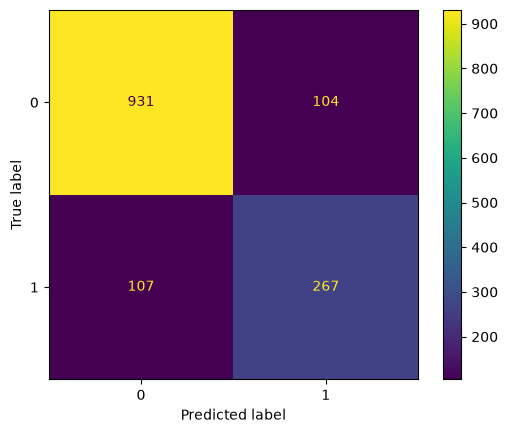

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

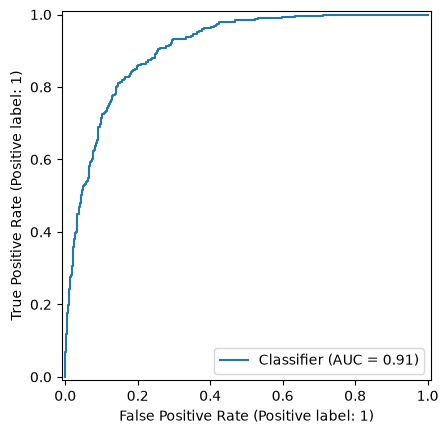

In [10]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)

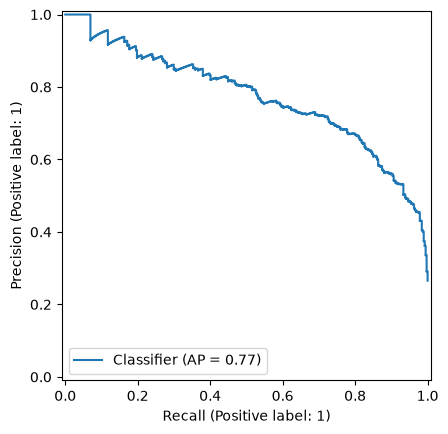

In [11]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_prob)

In [12]:
import joblib

joblib.dump(soft_voting, "../models/test1/soft_voting.pkl")

['../models/test1/soft_voting.pkl']